Sử dụng 13 cột khí tượng: ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 'precipitation', 'pressure', 'relative_humidity', 'temperature', 'uv_index', 'wind_speed']


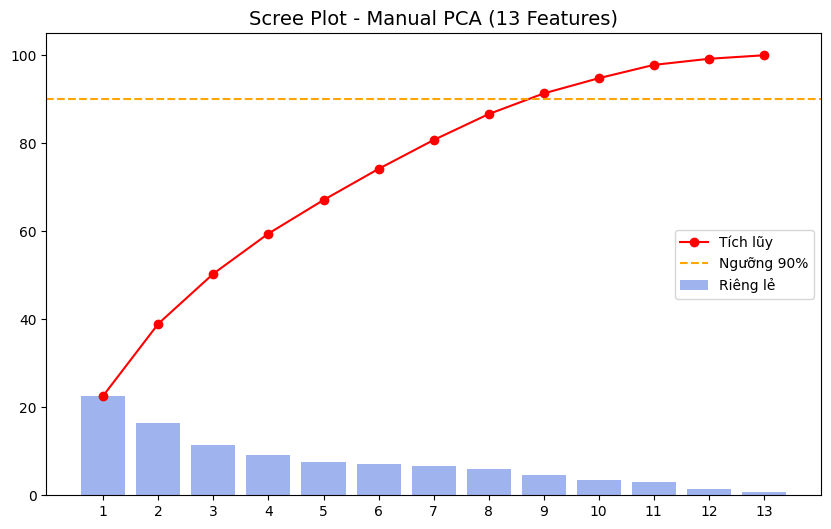

NHẬN XÉT: Giảm từ 13 biến xuống còn 9 biến chính để đạt >90% thông tin.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
try:
    df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
except:
    df = pd.read_csv('./clean/hanoi_aqi_cleaned.csv')

target_keywords = ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 
                   'precipitation', 'pressure', 'relative_humidity', 
                   'temperature', 'uv_index', 'wind_speed']

df.columns = df.columns.str.strip().str.lower() # Chuẩn hóa tên cột về chữ thường
cols_found = [c for c in df.columns if any(k == c for k in target_keywords)]

X = df[cols_found].apply(pd.to_numeric, errors='coerce').dropna()
X_values = X.values
n_features = X.shape[1]

print(f"Sử dụng {n_features} cột khí tượng: {cols_found}")

# 3. Tính toán PCA thủ công (Standardization)
# Kiểm tra nếu n_features > 0 để tránh lỗi chia cho 0
if n_features > 0:
    X_std = (X_values - np.mean(X_values, axis=0)) / (np.std(X_values, axis=0) + 1e-8)
    cov_mat = np.cov(X_std.T)
    
    # Giải quyết lỗi NaN trong ma trận hiệp phương sai
    cov_mat = np.nan_to_num(cov_mat)
    
    eigen_vals, _ = np.linalg.eig(cov_mat)
    sorted_eigen = np.sort(np.real(eigen_vals))[::-1]
    exp_var = (sorted_eigen / np.sum(sorted_eigen)) * 100
    cum_var = np.cumsum(exp_var)


    plt.figure(figsize=(10, 6))
    plt.bar(range(1, n_features + 1), exp_var, alpha=0.5, color='royalblue', label='Riêng lẻ')
    plt.plot(range(1, n_features + 1), cum_var, marker='o', color='red', label='Tích lũy')
    plt.axhline(y=90, color='orange', linestyle='--', label='Ngưỡng 90%')

    pc_90 = np.argmax(cum_var >= 90) + 1
    plt.title(f'Scree Plot - Manual PCA ({n_features} Features)', fontsize=14)
    plt.xticks(range(1, n_features + 1))
    plt.legend()
    plt.show()

    print(f"NHẬN XÉT: Giảm từ {n_features} biến xuống còn {pc_90} biến chính để đạt >90% thông tin.")
else:
    print("Không tìm thấy cột dữ liệu phù hợp!")